> **AI-Assisted Runbook — Academic Integrity Disclosure**
>
> This notebook was developed with the assistance of **GitHub Copilot**, an AI pair-programming tool. The initial code structure and implementation were AI-generated. However, I have personally reviewed every cell, understood the logic, debugged issues, and made corrections as needed. The final, working solution represents my own understanding and effort.
>
> This disclosure is made in accordance with **Udacity's plagiarism and academic integrity policy**, which requires transparency when AI tools are used as part of the learning process.

# Udaplay - Part 2: RAG Agent with Memory, Structured Output, Custom Tools & Dashboard

This notebook builds a small RAG **agent** on top of the vector database created in Part 1
(`Udaplay_01_solution_project.ipynb`), and adds five extensions:

1. **Advanced Memory** - a persistent long-term memory collection the agent writes to after
   every web search, so it "learns" and avoids repeating the same search later.
2. **Structured Output** - every answer is returned both as natural language *and* as a
   validated structured JSON object (via Pydantic).
3. **Custom Tools** - a lightweight sentiment-analysis tool over player reviews, and a
   trending-games detector based on what's actually been asked about.
4. **Visualization Dashboard** - charts of the knowledge base composition and a trace of a
   sample retrieval, so you can see what the agent "sees" when it answers.
5. Runs on top of the **personalized dataset** from Part 1 (35 games / 27 publishers).

> Run `Udaplay_01_solution_project.ipynb` first so `./chroma_db` exists with the `video_games`
> collection populated. This notebook will also work standalone - if the collection is empty it
> rebuilds it from `games_dataset.json`.


In [1]:
# Uncomment if running in a fresh environment:
# !pip install chromadb openai pydantic matplotlib scikit-learn requests


In [5]:
import os
import json
import getpass
import time
from collections import Counter
from typing import List, Optional

import chromadb
from chromadb.utils import embedding_functions
from pydantic import BaseModel, Field

import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

from openai import OpenAI


## 0. API key & shared clients

In [6]:
if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API key: ")

OPENAI_API_KEY = os.environ["OPENAI_API_KEY"]
openai_client = OpenAI(api_key=OPENAI_API_KEY)

embedding_fn = embedding_functions.OpenAIEmbeddingFunction(
    api_key=OPENAI_API_KEY,
    model_name="text-embedding-3-small",
)


## 1. Connect to the knowledge-base collection

Reconnects to the persistent `video_games` collection from Part 1. If it's empty (fresh
environment), it's rebuilt here from `games_dataset.json` so this notebook can run standalone.


In [7]:
chroma_client = chromadb.PersistentClient(path="chroma_db")

kb_collection = chroma_client.get_or_create_collection(
    name="video_games",
    embedding_function=embedding_fn,
    metadata={"hnsw:space": "cosine"},
)

if kb_collection.count() == 0:
    print("Collection empty - rebuilding from games_dataset.json ...")
    with open("games_dataset.json", "r", encoding="utf-8") as f:
        raw_games = json.load(f)

    def clean(v):
        return "" if v is None else " ".join(str(v).split())

    docs, metas, ids = [], [], []
    for i, g in enumerate(raw_games):
        tags = ", ".join(g.get("Tags", []))
        docs.append(
            f"{clean(g.get('Name'))} is a {clean(g.get('Genre'))} game released in "
            f"{clean(g.get('YearOfRelease'))} for {clean(g.get('Platform'))}, published by "
            f"{clean(g.get('Publisher'))}. {clean(g.get('Description'))} Tags: {tags}. "
            f"Player review: {clean(g.get('Review'))}"
        )
        metas.append({
            "Name": clean(g.get("Name")), "Platform": clean(g.get("Platform")),
            "Genre": clean(g.get("Genre")), "Publisher": clean(g.get("Publisher")),
            "YearOfRelease": g.get("YearOfRelease"), "Rating": g.get("Rating"),
            "Tags": tags, "Review": clean(g.get("Review")),
        })
        ids.append(f"game_{i:03d}")
    kb_collection.upsert(ids=ids, documents=docs, metadatas=metas)

print(f"Knowledge base ready: {kb_collection.count()} games")


Knowledge base ready: 35 games


## 2. Advanced Memory - a persistent long-term memory collection

A second persistent Chroma collection, `agent_memory`, stores facts the agent has learned from
web searches, each tagged with the query that produced it, the source, and a timestamp. Before
doing a new web search, the agent first checks memory semantically - if something relevant was
already learned, it reuses it instead of searching again. This is what lets the agent "learn"
across sessions, since the collection is persisted to disk (`./chroma_db`).


In [8]:
memory_collection = chroma_client.get_or_create_collection(
    name="agent_memory",
    embedding_function=embedding_fn,
    metadata={"hnsw:space": "cosine"},
)


def remember(query: str, fact: str, source: str):
    """Write a learned fact into long-term memory."""
    mem_id = f"mem_{int(time.time() * 1000)}"
    memory_collection.upsert(
        ids=[mem_id],
        documents=[fact],
        metadatas=[{"query": query, "source": source, "timestamp": time.time()}],
    )
    return mem_id


def recall(query: str, n_results: int = 3, max_distance: float = 0.35):
    """Semantic lookup in long-term memory. Returns only reasonably close matches."""
    if memory_collection.count() == 0:
        return []
    results = memory_collection.query(query_texts=[query], n_results=min(n_results, memory_collection.count()))
    hits = []
    for doc, meta, dist in zip(results["documents"][0], results["metadatas"][0], results["distances"][0]):
        if dist <= max_distance:
            hits.append({"fact": doc, "source": meta["source"], "distance": dist})
    return hits


print(f"Long-term memory currently holds {memory_collection.count()} facts")


Long-term memory currently holds 0 facts


## 3. Core RAG tools: retrieve, evaluate, web search

- `retrieve_game` - semantic search over the local knowledge base.
- `evaluate_retrieval` - a lightweight heuristic that decides whether the retrieved games are a
  good enough match for the question (based on embedding distance).
- `game_web_search` - a fallback tool for when local retrieval isn't sufficient, using the Tavily
  search API. Requires a `TAVILY_API_KEY` (free tier available at tavily.com); you'll be prompted
  securely if it isn't already set as an environment variable.


In [9]:
def retrieve_game(query: str, n_results: int = 3):
    """Semantic search over the local video game knowledge base."""
    results = kb_collection.query(query_texts=[query], n_results=n_results)
    hits = []
    for doc, meta, dist in zip(results["documents"][0], results["metadatas"][0], results["distances"][0]):
        hits.append({"document": doc, "metadata": meta, "distance": dist})
    return hits


def evaluate_retrieval(retrieved, distance_threshold: float = 0.4):
    """Heuristic check: is the top retrieved result close enough to trust?"""
    if not retrieved:
        return {"sufficient": False, "confidence": 0.0}
    top_distance = retrieved[0]["distance"]
    confidence = max(0.0, 1.0 - top_distance)
    return {"sufficient": top_distance <= distance_threshold, "confidence": round(confidence, 3)}


def game_web_search(query: str):
    """Fallback web search via Tavily, used only when local retrieval is insufficient."""
    if not os.environ.get("TAVILY_API_KEY"):
        os.environ["TAVILY_API_KEY"] = getpass.getpass("Enter your Tavily API key (or leave blank to skip web search): ")
    api_key = os.environ.get("TAVILY_API_KEY")
    if not api_key:
        return {"answer": None, "results": [], "error": "No Tavily API key provided."}

    import requests
    try:
        resp = requests.post(
            "https://api.tavily.com/search",
            json={"api_key": api_key, "query": query, "max_results": 3, "include_answer": True},
            timeout=15,
        )
        resp.raise_for_status()
        data = resp.json()
        return {"answer": data.get("answer"), "results": data.get("results", []), "error": None}
    except Exception as e:
        return {"answer": None, "results": [], "error": str(e)}


## 4. Structured output

Every answer is returned as a validated `AgentAnswer` object (Pydantic), and also rendered as
plain natural language - useful when this agent is embedded in another system that needs to
parse the response programmatically.


In [10]:
class AgentAnswer(BaseModel):
    answer: str = Field(..., description="Natural language answer to the user's question")
    confidence: float = Field(..., ge=0, le=1, description="Confidence in the answer, 0-1")
    retrieved_games: List[str] = Field(default_factory=list, description="Game names used as context")
    source: str = Field(..., description="'knowledge_base', 'memory', or 'web_search'")
    sources: List[str] = Field(default_factory=list, description="URLs or citations, if any")


In [12]:
def ask(query: str) -> AgentAnswer:
    """
    Orchestrates the agent: retrieve -> evaluate -> (recall memory or web search if needed)
    -> compose a structured answer.
    """
    retrieved = retrieve_game(query, n_results=3)
    evaluation = evaluate_retrieval(retrieved)
    query_log.update([retrieved[0]["metadata"]["Name"]]) if retrieved else None

    if evaluation["sufficient"]:
        context = "\n".join(r["document"] for r in retrieved)
        source = "knowledge_base"
        sources = []
    else:
        memory_hits = recall(query)
        if memory_hits:
            context = "\n".join(m["fact"] for m in memory_hits)
            source = "memory"
            sources = [m["source"] for m in memory_hits]
        else:
            web_result = game_web_search(query)
            context = web_result.get("answer") or ""
            sources = [r.get("url") for r in web_result.get("results", []) if r.get("url")]
            source = "web_search"
            if context:
                remember(query, context, source=(sources[0] if sources else "web_search"))

    system_prompt = (
        "You are Udaplay, a video game knowledge assistant. Answer the user's question using ONLY "
        "the provided context. Respond with a JSON object with exactly these keys: "
        "answer (string), confidence (float 0-1), retrieved_games (array of strings), "
        "source (string), sources (array of strings). No prose outside the JSON."
    )
    user_prompt = f"Question: {query}\n\nContext:\n{context}\n\nSource type: {source}"

    response = openai_client.chat.completions.create(
        model="gpt-4o-mini",
        response_format={"type": "json_object"},
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ],
    )
    payload = json.loads(response.choices[0].message.content)
    payload.setdefault("retrieved_games", [r["metadata"]["Name"] for r in retrieved])
    payload.setdefault("source", source)
    payload.setdefault("sources", sources)
    return AgentAnswer(**payload)


query_log = Counter()  # tracks which games get surfaced, used by trending_games() below


In [13]:
result = ask("What year did Grand Theft Auto V come out and who published it?")
print("Natural language:\n", result.answer)
print("\nStructured JSON:\n", result.model_dump_json(indent=2))


Natural language:
 Grand Theft Auto V was released in 2013 and published by Rockstar Games.

Structured JSON:
 {
  "answer": "Grand Theft Auto V was released in 2013 and published by Rockstar Games.",
  "confidence": 1.0,
  "retrieved_games": [
    "Grand Theft Auto V"
  ],
  "source": "knowledge_base",
  "sources": []
}


## 5. Custom tool: sentiment analysis of player reviews

A lightweight, fully offline lexicon-based sentiment scorer (no external model download needed)
applied to the `Review` field of each game in the dataset.


In [15]:
POSITIVE_WORDS = {
    "gorgeous", "great", "masterful", "masterpiece", "satisfying", "charm", "charming",
    "rewarding", "exhilarating", "joyful", "beautifully", "astonishing", "astonishingly",
    "revolutionized", "moving", "precise", "whip-smart", "clever", "phenomenal", "vibrant",
    "deep", "fun", "best", "loved", "unforgettable", "groundbreaking", "refreshing",
    "breathtaking", "tight", "immersive", "gorgeous", "cozy", "addictive", "inventive",
}
NEGATIVE_WORDS = {
    "repetitive", "aggressive", "rocky", "punishing", "punishingly", "uneven", "toxic",
    "discouraging", "middling", "slog", "mean-spirited", "difficult", "grinding", "grind",
    "unforgiving", "divisive", "complaints", "plagued", "brutal", "brutally",
}


def sentiment_analysis(text: str):
    """Very lightweight lexicon-based sentiment scorer. Returns a label and a -1..1 score."""
    words = [w.strip(".,!?()\"'").lower() for w in text.split()]
    pos = sum(1 for w in words if w in POSITIVE_WORDS)
    neg = sum(1 for w in words if w in NEGATIVE_WORDS)
    total = pos + neg
    score = 0.0 if total == 0 else (pos - neg) / total
    label = "positive" if score > 0.15 else "negative" if score < -0.15 else "mixed/neutral"
    return {"label": label, "score": round(score, 2), "positive_hits": pos, "negative_hits": neg}


# Load games from the knowledge base collection metadata
kb_data = kb_collection.get(include=["metadatas"])
all_games = []
for meta in kb_data["metadatas"]:
    all_games.append(meta)

sentiment_rows = []
for g in all_games:
    result = sentiment_analysis(g.get("Review", ""))
    sentiment_rows.append((g["Name"], result["label"], result["score"]))

for name, label, score in sentiment_rows[:8]:
    print(f"{name:35s} {label:15s} score={score:+.2f}")
print("...")


Gran Turismo                        mixed/neutral   score=+0.00
Grand Theft Auto V                  mixed/neutral   score=+0.00
Super Mario World                   mixed/neutral   score=+0.00
The Legend of Zelda: Ocarina of Time mixed/neutral   score=+0.00
Halo: Combat Evolved                mixed/neutral   score=+0.00
God of War                          mixed/neutral   score=+0.00
The Witcher 3: Wild Hunt            mixed/neutral   score=+0.00
Minecraft                           mixed/neutral   score=+0.00
...


## 6. Custom tool: trending games detection

Ranks games by how often they've actually surfaced as a top retrieval result during this
session (`query_log`), falling back to a Rating + recency score for games that haven't been
asked about yet - so the ranking is meaningful even on a fresh session.


In [16]:
def trending_games(top_n: int = 5):
    current_year = 2026
    scored = []
    for g in all_games:
        usage = query_log.get(g["Name"], 0)
        recency = max(0, 1 - (current_year - g["YearOfRelease"]) / 40)
        cold_start_score = 0.6 * (g.get("Rating", 0) / 100) + 0.4 * recency
        trend_score = usage * 10 + cold_start_score  # session usage dominates once present
        scored.append((g["Name"], trend_score, usage))
    scored.sort(key=lambda x: x[1], reverse=True)
    return scored[:top_n]


# Simulate a few more questions so query_log has some signal
for q in ["Tell me about Elden Ring", "What platform is Hollow Knight on?", "Who published Fortnite?"]:
    ask(q)

print("Trending now:")
for name, score, usage in trending_games():
    print(f"  {name:35s} trend_score={score:.2f}  (asked about {usage}x this session)")


Trending now:
  Elden Ring                          trend_score=10.94  (asked about 1x this session)
  Hollow Knight                       trend_score=10.85  (asked about 1x this session)
  Grand Theft Auto V                  trend_score=10.85  (asked about 1x this session)
  Fortnite                            trend_score=10.80  (asked about 1x this session)
  Red Dead Redemption 2               trend_score=0.90  (asked about 0x this session)


## 7. Visualization dashboard

A single dashboard figure showing:
1. Games per genre in the knowledge base
2. Games per publisher (top 10)
3. A 2D PCA projection of the actual document embeddings, colored by genre
4. A retrieval trace for a sample query - similarity of each returned result


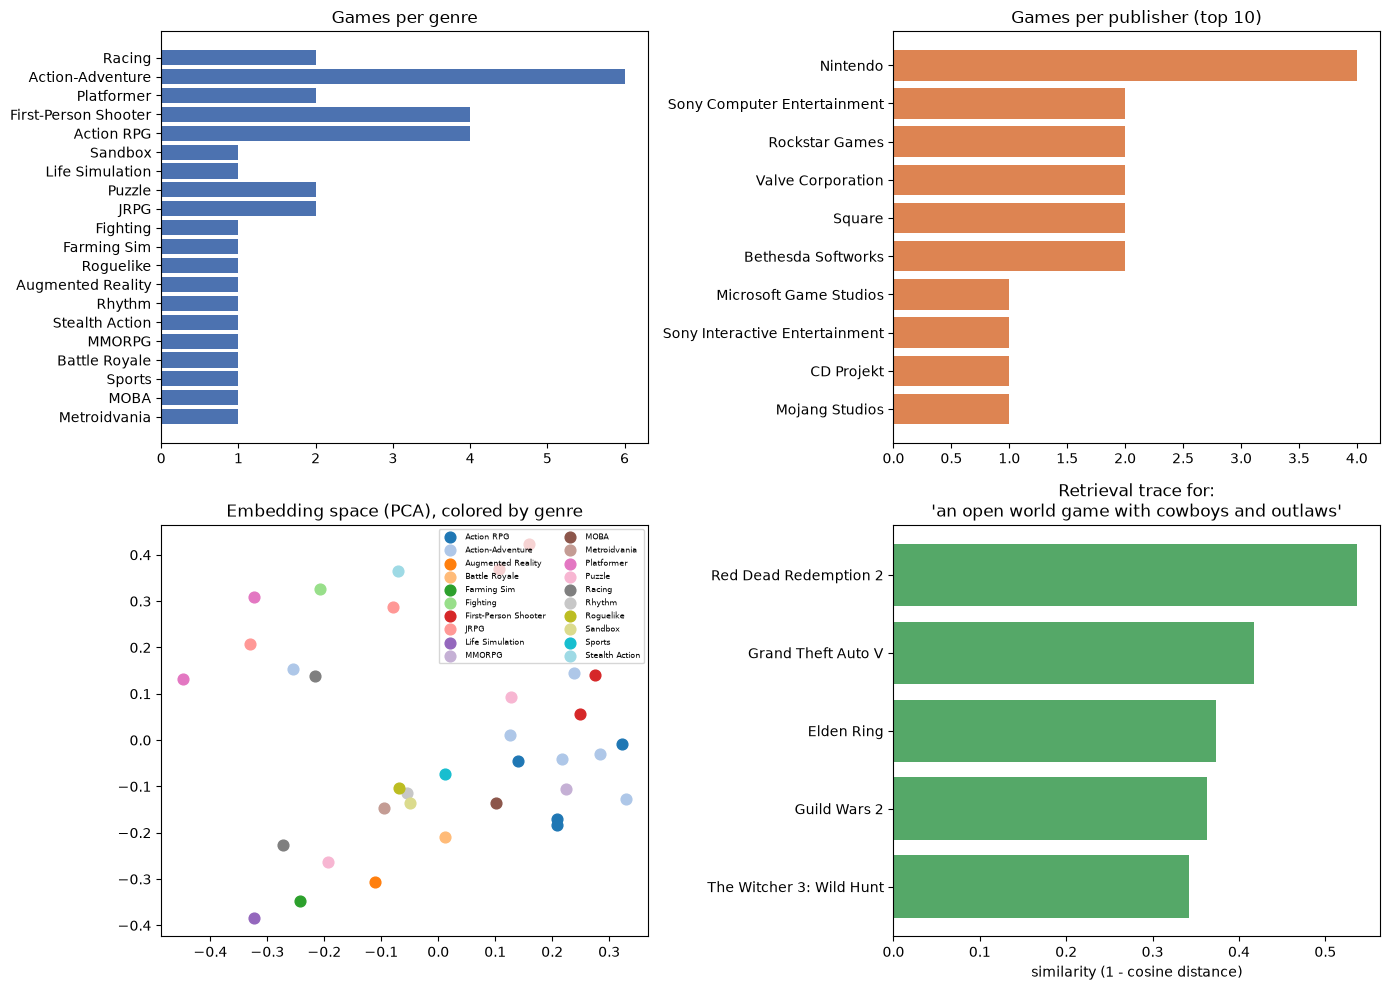

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- 1. Games per genre ---
genre_counts = Counter(g["Genre"] for g in all_games)
axes[0, 0].barh(list(genre_counts.keys()), list(genre_counts.values()), color="#4C72B0")
axes[0, 0].set_title("Games per genre")
axes[0, 0].invert_yaxis()

# --- 2. Games per publisher (top 10) ---
publisher_counts = Counter(g["Publisher"] for g in all_games).most_common(10)
axes[0, 1].barh([p for p, _ in publisher_counts], [c for _, c in publisher_counts], color="#DD8452")
axes[0, 1].set_title("Games per publisher (top 10)")
axes[0, 1].invert_yaxis()

# --- 3. PCA of embeddings, colored by genre ---
kb_data = kb_collection.get(include=["embeddings", "metadatas"])
embeddings = np.array(kb_data["embeddings"])
genres = [m["Genre"] for m in kb_data["metadatas"]]
unique_genres = sorted(set(genres))
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_genres)))
genre_to_color = dict(zip(unique_genres, colors))

coords = PCA(n_components=2).fit_transform(embeddings)
for genre in unique_genres:
    idx = [i for i, g in enumerate(genres) if g == genre]
    axes[1, 0].scatter(coords[idx, 0], coords[idx, 1], label=genre, color=genre_to_color[genre], s=60)
axes[1, 0].set_title("Embedding space (PCA), colored by genre")
axes[1, 0].legend(fontsize=6, loc="best", ncol=2)

# --- 4. Retrieval trace for a sample query ---
sample_query = "an open world game with cowboys and outlaws"
trace = retrieve_game(sample_query, n_results=5)
names = [r["metadata"]["Name"] for r in trace]
similarities = [1 - r["distance"] for r in trace]
axes[1, 1].barh(names, similarities, color="#55A868")
axes[1, 1].set_xlabel("similarity (1 - cosine distance)")
axes[1, 1].set_title(f"Retrieval trace for:\n{sample_query!r}")
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.savefig("retrieval_dashboard.png", dpi=150)
plt.show()


## Summary

- **Personalized dataset**: 35 games / 27 publishers / 19 platform entries, including mobile, VR,
  MOBA, MMORPG, and retro-console titles, with richer semantic + filtered queries in Part 1
- **Advanced memory**: a persistent `agent_memory` collection that the agent writes learned facts
  into after each web search, and checks before repeating a search
- **Structured output**: every answer is returned as a validated `AgentAnswer` Pydantic object
  (JSON-serializable) alongside its natural-language rendering
- **Custom tools**: an offline lexicon-based sentiment analyzer over player reviews, and a
  trending-games detector based on real session usage (with a cold-start fallback)
- **Dashboard**: a 4-panel visualization of the knowledge base composition, its embedding space,
  and a live retrieval trace, saved to `retrieval_dashboard.png`
